## Step 1 imports

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

## Step 2 load CIFAR again

In [3]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

C:\Users\SivaGuduri\Desktop\learn-ML\dl-env\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Filter cats/dogs:

In [4]:
train_mask = np.where((y_train == 3) | (y_train == 5))[0]
test_mask = np.where((y_test == 3) | (y_test == 5))[0]

X_train = X_train[train_mask]
y_train = y_train[train_mask]

X_test = X_test[test_mask]
y_test = y_test[test_mask]

Convert labels:

In [5]:
y_train = (y_train == 5).astype(int)
y_test = (y_test == 5).astype(int)

## Step 3 resize

In [6]:
X_train = tf.image.resize(X_train, (96, 96))
X_test = tf.image.resize(X_test, (96, 96))

In [7]:
print(X_train.shape)

(10000, 96, 96, 3)


## Step 4 normalize

MobileNet likes special preprocessing:

In [8]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

X_train = preprocess_input(X_train)
X_test = preprocess_input(X_test)

## Step 5 — Load MobileNetV2
weights="imagenet"

Load pretrained knowledge.
Meaning: this model already learned from millions of images

In [10]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(96, 96, 3),
    include_top=False,
    weights="imagenet"
)

## Step 6 — Freeze pretrained layers
Meaning:
DON'T modify MobileNet's learned knowledge
We use it as a frozen expert.
Only our new classifier learns.

In [12]:
base_model.trainable = False

## Step 7 — Build our custom model

In [13]:
model = tf.keras.Sequential([
    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(128, activation="relu"),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(1, activation="sigmoid")
])

## Step 8 — Compile

In [18]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [19]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_mobilenet_model.keras",
    monitor="val_accuracy",
    save_best_only=True
)

## Step 9 — Train

In [20]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, checkpoint]
)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 106ms/step - accuracy: 0.9261 - loss: 0.1824 - val_accuracy: 0.8770 - val_loss: 0.3089
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 111ms/step - accuracy: 0.9362 - loss: 0.1569 - val_accuracy: 0.8720 - val_loss: 0.3214
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 112ms/step - accuracy: 0.9502 - loss: 0.1313 - val_accuracy: 0.8750 - val_loss: 0.3376
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 37s 118ms/step - accuracy: 0.9582 - loss: 0.1091 - val_accuracy: 0.8700 - val_loss: 0.3514


## prediction

In [30]:
predictions = model.predict(X_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step


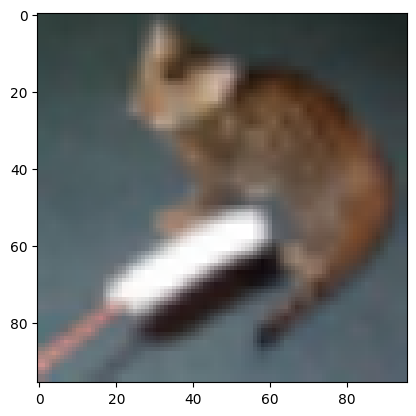

Predicted: Cat
Actual: Cat


In [31]:
index = 20

plt.imshow((X_test[index] + 1) / 2)
plt.show()

pred = predictions[index][0]

if pred > 0.5:
    print("Predicted: Dog")
else:
    print("Predicted: Cat")

print("Actual:", "Dog" if y_test[index] == 1 else "Cat")

## Model Evaluation

In [32]:
!pip install scikit-learn


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
from sklearn.metrics import confusion_matrix, classification_report

In [35]:
y_pred = (predictions > 0.5).astype(int)
print(y_pred[:10])

[[0]
 [0]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [0]]


## Confusion matrix

In [36]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[874 126]
 [120 880]]


## Full report

In [37]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.87      0.88      1000
           1       0.87      0.88      0.88      1000

    accuracy                           0.88      2000
   macro avg       0.88      0.88      0.88      2000
weighted avg       0.88      0.88      0.88      2000

